## Importing libraries

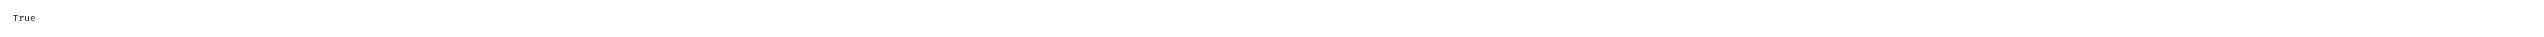

In [ ]:
import marimo as mo
import yt_dlp
import whisper
import json
import os
import re
import subprocess
import base64
from groq import Groq
from dotenv import load_dotenv
load_dotenv("/home/s5823597/Desktop/SEM/flavourflow/.env")

## Setting up Tiktok Url

In [ ]:
url = "https://www.tiktok.com/@zachsfoods/video/7595255804333149470" # TikTok video URL

## Fetching Video Metadata

In [ ]:
with yt_dlp.YoutubeDL({'quiet': True}) as ydl_meta:
    data = ydl_meta.extract_info(url, download=False)

## Display Metadata

In [ ]:
print("Title:", data.get("title", "N/A"))  # video title
print("Uploader:", data.get("uploader", "N/A"))  # creator name
print("Description:", data.get("description", "N/A")) # video caption
print("Duration:", data.get("duration", "N/A"), "seconds") # video length
print("View count:", data.get("view_count", "N/A"))  # total views

Title: Honey Garlic Chicken!  #easyrecipe #cooking #easydinner #asianfood #r...
Uploader: zachsfoods
Description: Honey Garlic Chicken!  #easyrecipe #cooking #easydinner #asianfood #ricebowl  For the meat 🍗: 1lb chicken thighs 2 tsp canola oil Salt, Pepper to taste 2 tbsp cornstarch (enough to coat) For the sauce: 1.5 tbsp low sodium soy sauce 3 tbsp honey 2 tbsp water 1/2 tbsp sugar 1/2 tsp red pepper flakes 1/2 tsp paprika 3 garlic cloves (minced) 2 tbsp green onion whites
Duration: 27 seconds
View count: 11300000


## Download Video and Check for Subtitles

In [ ]:
os.makedirs("outputs", exist_ok=True)  # create outputs folder if it doesn't exist

ydl_opts = {
    'writesubtitles': True,
    'subtitleslangs': ['all'],
    'writeautomaticsub': True,
    'outtmpl': 'outputs/%(id)s.%(ext)s',
    'quiet': True,
}
with yt_dlp.YoutubeDL(ydl_opts) as ydl_dl:
    ydl_dl.download([url])

video_id = url.split("/")[-1].split("?")[0]  # extract video ID from URL
video_file = None  # will store video file path
subtitle_file = None  # will store subtitle file path

for fname in os.listdir("outputs"):  # loop through downloaded files
    if video_id in fname and fname.endswith(".mp4"):  # find the video file
        video_file = f"outputs/{fname}"
    if video_id in fname and (".vtt" in fname or ".srt" in fname):  # find subtitle file
        subtitle_file = f"outputs/{fname}"

print("Video:", video_file)  # show video path
print("Subtitles:", subtitle_file)  # show subtitle path (None if no subs)

Video: outputs/7595255804333149470.mp4
Subtitles: outputs/7595255804333149470.eng-US.vtt


## Extract Speech Text from Subtitles

In [ ]:
speech_text = ""

if subtitle_file:  # subtitles found, use them
    with open(subtitle_file, "r") as sub_file:
        lines = sub_file.readlines()
    for line in lines:  # filter out timestamps and metadata
        line = line.strip()
        if line and not line.startswith("WEBVTT") and "-->" not in line and not line.isdigit():
            speech_text += line + " "
    print("Source: TikTok subtitles")
elif video_file:  # no subtitles — fall back to Whisper ASR
    print("No subtitles found — running Whisper ASR...")
    whisper_model = whisper.load_model("base")
    whisper_result = whisper_model.transcribe(video_file)
    speech_text = whisper_result["text"]
    print("Source: Whisper ASR")
else:
    print("No video or subtitles found — cannot extract speech")

print("\nSpeech text:")
print(speech_text.strip())

Source: TikTok subtitles

Speech text:
I'm an amateur cook trying to show you that cooking is really not that hard. And this is honey, garlic chicken. Start your chicken, salt, pepper, a little bit of oil, cornstarch. Just mix until that's all nice and coated. Soy sauce. Soy sauce, lots of honey, red pepper flakes, little paprika, water, garlic, more garlic, sugar. With that together, heat some oil, add your chicken in. Cook until 1 65 and nice and golden brown. Then in the same pan, add your green onion whites. As your butter melts down, add in your sauce. Mixture should start to thicken up quite a bit. And that's definitely quicker than takeout, which is great because


## Vision Analysis — Frame Extraction

In [ ]:
visual_description = ""

if video_file:
    frames_dir = f"outputs/frames_{os.path.basename(video_file).split('.')[0]}"
    os.makedirs(frames_dir, exist_ok=True)

    # extract 5 evenly spaced frames using ffmpeg
    subprocess.run([
        "ffmpeg", "-i", video_file,
        "-vf", "fps=1/3", "-vframes", "5",
        f"{frames_dir}/frame_%02d.jpg",
        "-y", "-loglevel", "error"
    ])

    frames = sorted([
        f"{frames_dir}/{f}" for f in os.listdir(frames_dir) if f.endswith(".jpg")
    ])
    print(f"Extracted {len(frames)} frames: {frames}")

    # encode frames as base64 and send to Groq vision model
    groq_api_key = os.environ.get("GROQ_API_KEY", "")
    if groq_api_key and frames:
        groq_vision_client = Groq(api_key=groq_api_key)

        image_content = []
        for frame_path in frames:
            with open(frame_path, "rb") as img_file:
                b64 = base64.b64encode(img_file.read()).decode("utf-8")
            image_content.append({
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{b64}"}
            })
        image_content.append({
            "type": "text",
            "text": "These are frames from a TikTok cooking video. Describe what ingredients, cooking techniques, and dishes you can see. Be specific and concise."
        })

        vision_response = groq_vision_client.chat.completions.create(
            model="meta-llama/llama-4-scout-17b-16e-instruct",
            messages=[{"role": "user", "content": image_content}],
            max_tokens=512,
        )
        visual_description = vision_response.choices[0].message.content
        print("Visual description:")
        print(visual_description)
    else:
        print("No Groq API key or frames — skipping vision analysis")
else:
    print("No video file — skipping vision analysis")

Extracted 5 frames: ['outputs/frames_7595255804333149470/frame_01.jpg', 'outputs/frames_7595255804333149470/frame_02.jpg', 'outputs/frames_7595255804333149470/frame_03.jpg', 'outputs/frames_7595255804333149470/frame_04.jpg', 'outputs/frames_7595255804333149470/frame_05.jpg']
Visual description:
The images from a TikTok cooking video depict a person preparing and showcasing General Tso Chicken with rice.

**Ingredients:**
* Rice
* Green onions
* Chicken
* Sesame seeds
* A sauce composed of ingredients such as soy sauce

**Cooking Techniques:**
* Coating
* Frying
* Sauce making

**Dishes:**
* General Tso Chicken with rice

The video likely provides step-by-step instructions on how to prepare this popular Chinese-American dish.


## Extract Structured Recipe

In [ ]:
groq_client = Groq(api_key=os.environ.get("GROQ_API_KEY", ""))

context = f"""
Video Title: {data.get("title", "")}
Video Description: {data.get("description", "")}
Speech Transcript: {speech_text.strip()}
Visual Description: {visual_description.strip()}
"""

prompt = f"""You are a recipe extraction AI. Analyse the following TikTok video data and:

1. Determine if this is a cooking video (YES/NO)
2. If YES, extract a structured recipe in JSON format with these fields:
   - dish_name
   - cuisine_type
   - difficulty (easy/medium/hard)
   - prep_time
   - cook_time
   - servings
   - ingredients (list with quantity and item)
   - steps (numbered list)
   - halal_status (halal/not_halal/uncertain with reason)

IMPORTANT: The video may be in any language (Arabic, Malay, Chinese, etc.).
You MUST translate ALL field values into English. Every single value in the JSON — including dish_name, ingredients, and steps — must be written in English. Do not use any other language in your response.

Video Data:
{context}

Respond ONLY in valid JSON."""

messages = [
    {"role": "system", "content": "You are a recipe extraction assistant. Always respond in valid JSON in English only, even if the video is in another language."},
    {"role": "user", "content": prompt}
]

groq_response = groq_client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=messages,
    max_tokens=1024,
    temperature=0.1,
)
response = groq_response.choices[0].message.content

cleaned_single = re.sub(r'```(?:json)?\s*', '', response).strip()
try:
    json_match_single = re.search(r'\{.*\}', cleaned_single, re.DOTALL)
    recipe = json.loads(json_match_single.group()) if json_match_single else {}
    if "recipe" in recipe and isinstance(recipe["recipe"], dict):
        recipe = recipe["recipe"]
except Exception:
    recipe = {}

print(json.dumps(recipe, indent=2, ensure_ascii=False) if recipe else response)

{
  "dish_name": "Honey Garlic Chicken",
  "cuisine_type": "Asian",
  "difficulty": "easy",
  "prep_time": "Not specified",
  "cook_time": "Not specified",
  "servings": "Not specified",
  "ingredients": [
    {
      "quantity": "1lb",
      "item": "chicken thighs"
    },
    {
      "quantity": "2 tsp",
      "item": "canola oil"
    },
    {
      "quantity": "to taste",
      "item": "salt"
    },
    {
      "quantity": "to taste",
      "item": "pepper"
    },
    {
      "quantity": "2 tbsp",
      "item": "cornstarch"
    },
    {
      "quantity": "1.5 tbsp",
      "item": "low sodium soy sauce"
    },
    {
      "quantity": "3 tbsp",
      "item": "honey"
    },
    {
      "quantity": "2 tbsp",
      "item": "water"
    },
    {
      "quantity": "0.5 tbsp",
      "item": "sugar"
    },
    {
      "quantity": "0.5 tsp",
      "item": "red pepper flakes"
    },
    {
      "quantity": "0.5 tsp",
      "item": "paprika"
    },
    {
      "quantity": "3 cloves",
      "item

## Test Suite — 4 Languages

In [ ]:
test_videos = [
    {"language": "English", "url": "https://www.tiktok.com/@zachsfoods/video/7595255804333149470"},
    {"language": "Malay",   "url": "https://www.tiktok.com/@syiqinazrin/video/7608900115130027284"},
    {"language": "Arabic",  "url": "https://www.tiktok.com/@danahnalshaya/video/7059812099437956354"},
    {"language": "Chinese", "url": "https://www.tiktok.com/@hhfghvgfj/video/7435622193951739154"},
]

In [ ]:
os.makedirs("outputs", exist_ok=True)

test_results = []

for video in test_videos:
    lang = video["language"]
    url_t = video["url"]
    print(f"\n--- {lang} ---")

    # fetch metadata
    with yt_dlp.YoutubeDL({'quiet': True}) as ydl_t:
        meta = ydl_t.extract_info(url_t, download=False)

    # download video + subtitles
    ydl_opts_t = {
        'writesubtitles': True,
        'subtitleslangs': ['all'],
        'writeautomaticsub': True,
        'outtmpl': 'outputs/%(id)s.%(ext)s',
        'quiet': True,
    }
    with yt_dlp.YoutubeDL(ydl_opts_t) as ydl_t2:
        ydl_t2.download([url_t])

    video_id_t = url_t.split("/")[-1].split("?")[0]
    video_file_t = None
    subtitle_file_t = None
    for fname_t in os.listdir("outputs"):
        if video_id_t in fname_t and fname_t.endswith(".mp4"):
            video_file_t = f"outputs/{fname_t}"
        if video_id_t in fname_t and (".vtt" in fname_t or ".srt" in fname_t):
            subtitle_file_t = f"outputs/{fname_t}"

    # extract speech
    speech_t = ""
    if subtitle_file_t:
        with open(subtitle_file_t, "r") as sf:
            for line_t in sf.readlines():
                line_t = line_t.strip()
                if line_t and not line_t.startswith("WEBVTT") and "-->" not in line_t and not line_t.isdigit():
                    speech_t += line_t + " "
        source_t = "subtitles"
    elif video_file_t:
        whisper_model_t = whisper.load_model("base")
        speech_t = whisper_model_t.transcribe(video_file_t)["text"]
        source_t = "whisper"
    else:
        source_t = "none"

    print(f"Speech source: {source_t}")
    print(f"Title: {meta.get('title', 'N/A')}")
    print(f"Speech preview: {speech_t.strip()[:200]}")

    test_results.append({
        "language": lang,
        "url": url_t,
        "title": meta.get("title", ""),
        "speech_source": source_t,
        "speech_text": speech_t.strip(),
        "description": meta.get("description", ""),
    })

print("\nAll videos processed.")


--- English ---
Speech source: subtitles
Title: Honey Garlic Chicken!  #easyrecipe #cooking #easydinner #asianfood #r...
Speech preview: I'm an amateur cook trying to show you that cooking is really not that hard. And this is honey, garlic chicken. Start your chicken, salt, pepper, a little bit of oil, cornstarch. Just mix until that's

--- Malay ---
Speech source: subtitles
Title: post time sekarang okay tak hehe selamat berbuka semua! #easyrecipe #...
Speech preview: The recipe for day two of this year's fast. I want to make an omelette cooked in student fat. Very happy edition. What you confirm to do and become. so let's try again. I looked in the kitchen at the 

--- Arabic ---
Speech source: whisper
Title: اللي راح يجربها يكتب بالتعليقات باعرف ذوقكم بالاكل 😍👌🏻#حمسة_باذنجان #...
Speech preview: حمثة بذنجان سهلا ولذي ذا أنت راح توافقون الرعي آخر المكتع يلاعى المطفخ ابزيت أحمس بصال ثوم عليها في الف الحار وأجل لب وأضيف لها شويت كسبرة مفرومة وهنا أضفت صلسة التماطم وأجل لب بعدها أضيف ع

## Evaluation — Scoring Table

In [ ]:
groq_eval_client = Groq(api_key=os.environ.get("GROQ_API_KEY", ""))
eval_rows = []

for test_result in test_results:
    context_e = f"""
    Video Title: {test_result['title']}
    Video Description: {test_result['description']}
    Speech Transcript: {test_result['speech_text'][:500]}
    """

    prompt_e = f"""You are a recipe extraction AI. Analyse the following TikTok video data and:

    1. Determine if this is a cooking video (YES/NO)
    2. If YES, extract a structured recipe in JSON format with these fields:
       - dish_name
       - cuisine_type
       - difficulty (easy/medium/hard)
       - prep_time
       - cook_time
       - servings
       - ingredients (list with quantity and item)
       - steps (numbered list)
       - halal_status (halal/not_halal/uncertain with reason)

    IMPORTANT: The video may be in any language (Arabic, Malay, Chinese, etc.).
    You MUST translate ALL field values into English. Every single value in the JSON — including dish_name, ingredients, and steps — must be written in English. Do not use any other language in your response.

    Video Data:
    {context_e}

    Respond ONLY in valid JSON."""

    messages_e = [
        {"role": "system", "content": "You are a recipe extraction assistant. Always respond in valid JSON in English only."},
        {"role": "user", "content": prompt_e}
    ]

    groq_resp_e = groq_eval_client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=messages_e,
        max_tokens=1024,
        temperature=0.1,
    )
    response_e = groq_resp_e.choices[0].message.content

    try:
        cleaned_e = re.sub(r'```(?:json)?\s*', '', response_e).strip()
        json_match_e = re.search(r'\{.*\}', cleaned_e, re.DOTALL)
        recipe_e = json.loads(json_match_e.group()) if json_match_e else {}
        if "recipe" in recipe_e and isinstance(recipe_e["recipe"], dict):
            recipe_e = recipe_e["recipe"]
    except Exception:
        recipe_e = {}

    print(f"[{test_result['language']}] raw response preview: {response_e[:200]}")
    print(f"[{test_result['language']}] parsed recipe keys: {list(recipe_e.keys())}")

    dish_ok  = bool(str(recipe_e.get("dish_name", "")).strip())
    ingr_ok  = len(recipe_e.get("ingredients", [])) >= 2
    steps_ok = len(recipe_e.get("steps", [])) >= 2
    score    = sum([dish_ok, ingr_ok, steps_ok])

    eval_rows.append({
        "Language":      test_result["language"],
        "Dish Name":     recipe_e.get("dish_name", "—"),
        "Dish ✓":        "✓" if dish_ok  else "✗",
        "Ingredients ✓": "✓" if ingr_ok  else "✗",
        "Steps ✓":       "✓" if steps_ok else "✗",
        "Score":         f"{score}/3",
    })

eval_table = mo.ui.table(eval_rows)

[English] raw response preview: ```
{
  "is_cooking_video": "YES",
  "recipe": {
    "dish_name": "Honey Garlic Chicken",
    "cuisine_type": "Asian",
    "difficulty": "easy",
    "prep_time": "Not specified",
    "cook_time": "Not
[English] parsed recipe keys: ['dish_name', 'cuisine_type', 'difficulty', 'prep_time', 'cook_time', 'servings', 'ingredients', 'steps', 'step_descriptions', 'halal_status', 'halal_reason']
[Malay] raw response preview: ```
{
  "is_cooking_video": "YES",
  "recipe": {
    "dish_name": "Omelette Cooked in Fat",
    "cuisine_type": "Malaysian",
    "difficulty": "easy",
    "prep_time": "Not specified",
    "cook_time"
[Malay] parsed recipe keys: ['dish_name', 'cuisine_type', 'difficulty', 'prep_time', 'cook_time', 'servings', 'ingredients', 'steps', 'halal_status', 'reason']
[Arabic] raw response preview: ```
{
  "is_cooking_video": "YES",
  "recipe": {
    "dish_name": "Eggplant Delight",
    "cuisine_type": "Middle Eastern",
    "difficulty": "easy",
    "p

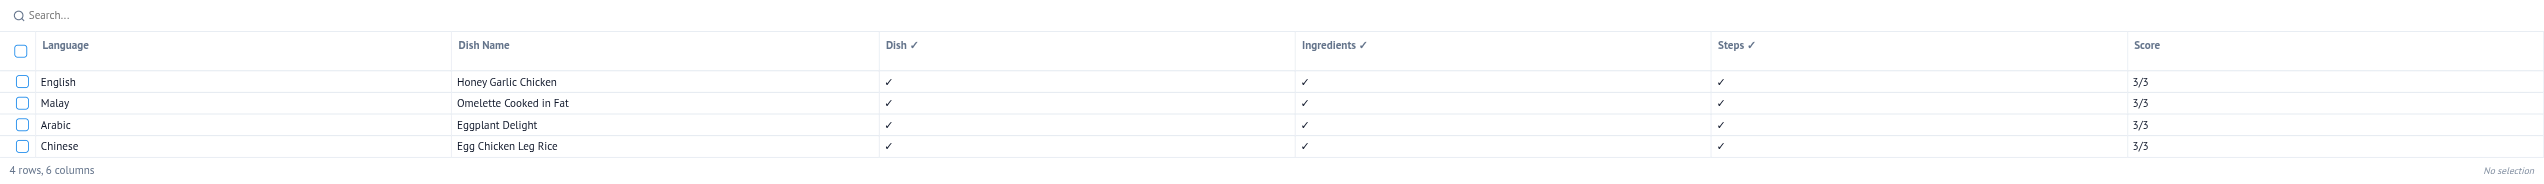

In [ ]:
eval_table